1 kanal

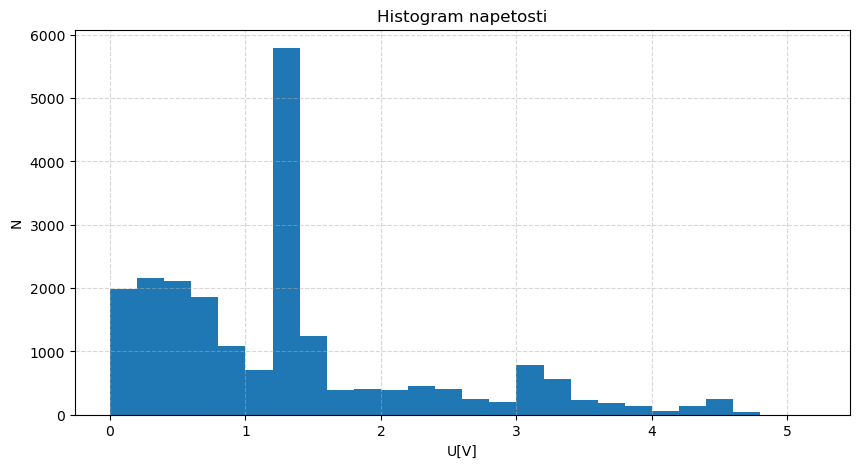

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Podatki
U = np.array([
    0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8,
    2, 2.2, 2.4, 2.6, 2.8, 3, 3.2, 3.4, 3.6, 3.8,
    4, 4.2, 4.4, 4.6, 4.8, 5
])

N = np.array([
    1983, 2158, 2110, 1853, 1081, 700, 5792, 1249, 392, 404,
    384, 460, 404, 245, 206, 782, 564, 227, 179, 142,
    64, 142, 241, 41, 3, 1
])

# Histogram / stolpčni diagram
plt.figure(figsize=(10,5))
plt.bar(U+0.1, N, width=0.2)
plt.xlabel("U[V]")
plt.ylabel("N")
plt.title("Histogram napetosti")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("Na_en kanal.pdf")
plt.show()


večkanalna umeritev

[ 0.50394737 12.09210526]
127217.0
487.0


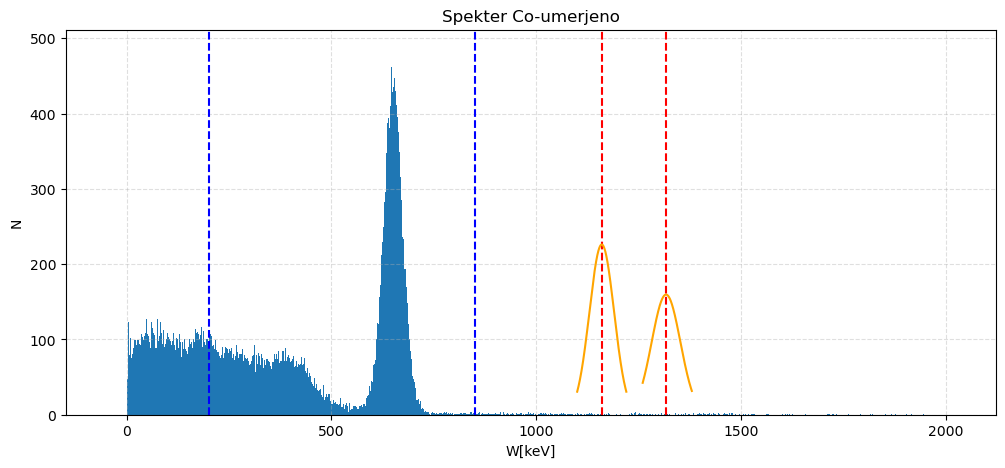

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

y=np.array([511, 1277])
x=np.array([990,2510])
p=np.polyfit(x,y,1)
print(p)

def read_mca(filename):
    data = []
    inside = False

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line == "<<DATA>>":
                inside = True
                continue

            if line == "<<END>>":
                break

            if inside:
                try:
                    value = float(line)
                    data.append(value)
                except:
                    pass

    return np.array(data)


# Naloži podatke iz .mca
filename = "cs.mca"
data = read_mca(filename)
print(np.sum(data))
print(max(data))

# Os X = indeks kanala
x = np.arange(len(data))
x-=113
x = p[0]*x + p[1]
x_gauss1=np.linspace(1100, 1220, 10000)
x_gauss2=np.linspace(1260, 1380, 10000)

# Risanje spektra
plt.figure(figsize=(12, 5))
plt.axvline(x=1160, ls="--", color="red")
plt.axvline(x=1317, ls="--", color="red")
plt.plot(x_gauss1, 17000*norm.pdf(x_gauss1, 1160, 30), color="orange")
plt.plot(x_gauss2, 14000*norm.pdf(x_gauss2, 1317, 35), color="orange")
plt.axvline(x=200, ls="--", color="blue")
plt.axvline(x=850, ls="--", color="blue")
plt.bar(x, data, width=1.0)
plt.xlabel("W[keV]")
plt.ylabel("N")
plt.title("Spekter Co-umerjeno")
plt.grid(True, linestyle="--", alpha=0.4)
#plt.savefig("Co_umerjeno.pdf")
plt.show()
